In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('amazon_sales_2025_INR.csv')

In [110]:
df

,Order_ID,Date,Customer_ID,Product_Category,Product_Name,Quantity,Unit_Price_INR,Total_Sales_INR,Payment_Method,Delivery_Status,Review_Rating,Review_Text,State,Country
0,ORD100000,2025-01-25,CUST2796,Home & Kitchen,Cookware Set,2,25574.41,51148.82,Credit Card,Returned,1,Waste of money,Sikkim,India
1,ORD100001,2025-08-28,CUST9669,Beauty,Hair Dryer,1,19361.41,19361.41,Debit Card,Returned,5,Excellent product!,Telangana,India
2,ORD100002,2025-02-27,CUST5808,Electronics,Tablet,3,38476.22,115428.66,Cash on Delivery,Delivered,3,Fair deal,Nagaland,India
3,ORD100003,2025-02-24,CUST5889,Electronics,Headphones,5,38145.72,190728.60,Credit Card,Delivered,5,Highly recommend!,Assam,India
4,ORD100004,2025-06-15,CUST9005,Clothing,Saree,5,45940.98,229704.90,UPI,Delivered,5,Highly recommend!,Odisha,India
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,ORD114995,2025-04-12,CUST2822,Beauty,Lipstick,4,36421.54,145686.16,UPI,Delivered,1,Never buying again,Gujarat,India
14996,ORD114996,2025-08-29,CUST6143,Beauty,Shampoo,4,18158.02,72632.08,Debit Card,Delivered,4,Satisfied with the product,Meghalaya,India
14997,ORD114997,2025-01-27,CUST6747,Books,Science Textbook,1,38864.05,38864.05,UPI,Delivered,1,Waste of money,Sikkim,India
14998,ORD114998,2025-06-21,CUST2748,Beauty,Hair Dryer,3,32658.62,97975.86,Cash on Delivery,Pending,3,Okay product,Himachal Pradesh,India


In [111]:
df['Date'] = pd.to_datetime(df['Date'])
a = df['Date'].dtype
a

dtype('<M8[ns]')

In [112]:
df['Month_Name'] = df['Date'].dt.month_name()   
df['Month_Num'] = df['Date'].dt.month           

In [113]:
monthly_sales = (df.groupby(['Month_Num', 'Month_Name'])['Total_Sales_INR'].sum().reset_index().sort_values('Month_Num'))

In [114]:
monthly_sales

,Month_Num,Month_Name,Total_Sales_INR
0,1,January,92051785.03
1,2,February,84995760.62
2,3,March,93064349.39
3,4,April,91388990.14
4,5,May,97195848.48
5,6,June,89730685.72
6,7,July,95176904.42
7,8,August,97576563.09
8,9,September,91225555.74
9,10,October,93478344.05


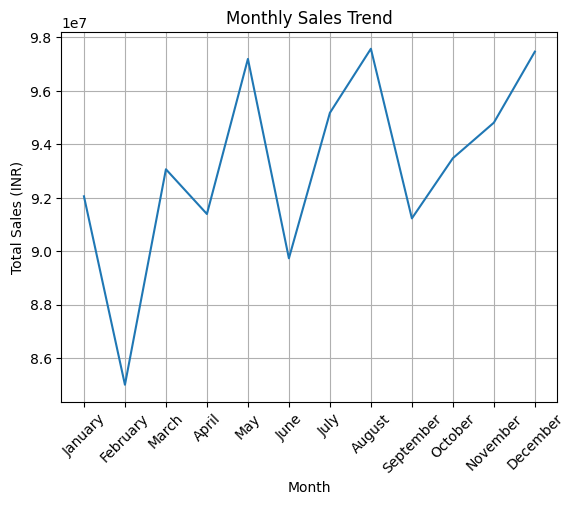

In [115]:
plt.plot(monthly_sales['Month_Name'], monthly_sales['Total_Sales_INR'])
plt.xlabel('Month')
plt.ylabel('Total Sales (INR)')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [ ]:
df 

,Order_ID,Date,Customer_ID,Product_Category,Product_Name,Quantity,Unit_Price_INR,Total_Sales_INR,Payment_Method,Delivery_Status,Review_Rating,Review_Text,State,Country,Month_Name,Month_Num
0,ORD100000,2025-01-25,CUST2796,Home & Kitchen,Cookware Set,2,25574.41,51148.82,Credit Card,Returned,1,Waste of money,Sikkim,India,January,1
1,ORD100001,2025-08-28,CUST9669,Beauty,Hair Dryer,1,19361.41,19361.41,Debit Card,Returned,5,Excellent product!,Telangana,India,August,8
2,ORD100002,2025-02-27,CUST5808,Electronics,Tablet,3,38476.22,115428.66,Cash on Delivery,Delivered,3,Fair deal,Nagaland,India,February,2
3,ORD100003,2025-02-24,CUST5889,Electronics,Headphones,5,38145.72,190728.60,Credit Card,Delivered,5,Highly recommend!,Assam,India,February,2
4,ORD100004,2025-06-15,CUST9005,Clothing,Saree,5,45940.98,229704.90,UPI,Delivered,5,Highly recommend!,Odisha,India,June,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,ORD114995,2025-04-12,CUST2822,Beauty,Lipstick,4,36421.54,145686.16,UPI,Delivered,1,Never buying again,Gujarat,India,April,4
14996,ORD114996,2025-08-29,CUST6143,Beauty,Shampoo,4,18158.02,72632.08,Debit Card,Delivered,4,Satisfied with the product,Meghalaya,India,August,8
14997,ORD114997,2025-01-27,CUST6747,Books,Science Textbook,1,38864.05,38864.05,UPI,Delivered,1,Waste of money,Sikkim,India,January,1
14998,ORD114998,2025-06-21,CUST2748,Beauty,Hair Dryer,3,32658.62,97975.86,Cash on Delivery,Pending,3,Okay product,Himachal Pradesh,India,June,6


In [117]:
product_sales = (df.groupby('Product_Name')['Total_Sales_INR'].sum().sort_values(ascending=False))

In [118]:
product_sales

Product_Name
Lipstick            48159020.15
Children's Book     48145664.52
Headphones          48044405.75
Hair Dryer          47428844.81
Perfume             46284732.62
Laptop              46173868.15
Tablet              46170022.15
Sneakers            46057295.93
Air Fryer           45919707.91
Jeans               45232819.47
Comics              45027269.77
Fiction Novel       44408345.45
Cookware Set        44375328.48
Jacket              44260811.71
Smartwatch          44005090.59
Biography           43811479.10
Science Textbook    43606467.72
Saree               43532090.95
Face Cream          43464123.14
Mixer Grinder       43449507.67
T-Shirt             43326317.77
Smartphone          42171536.69
Shampoo             42152903.96
Water Purifier      41724792.43
Vacuum Cleaner      41229356.61
Name: Total_Sales_INR, dtype: float64

In [119]:
best_selling_product = product_sales.idxmax()
best_selling_value = product_sales.max()

print("Best-selling product:", best_selling_product)
print("Total sales (INR):", best_selling_value)

Best-selling product: Lipstick
Total sales (INR): 48159020.15


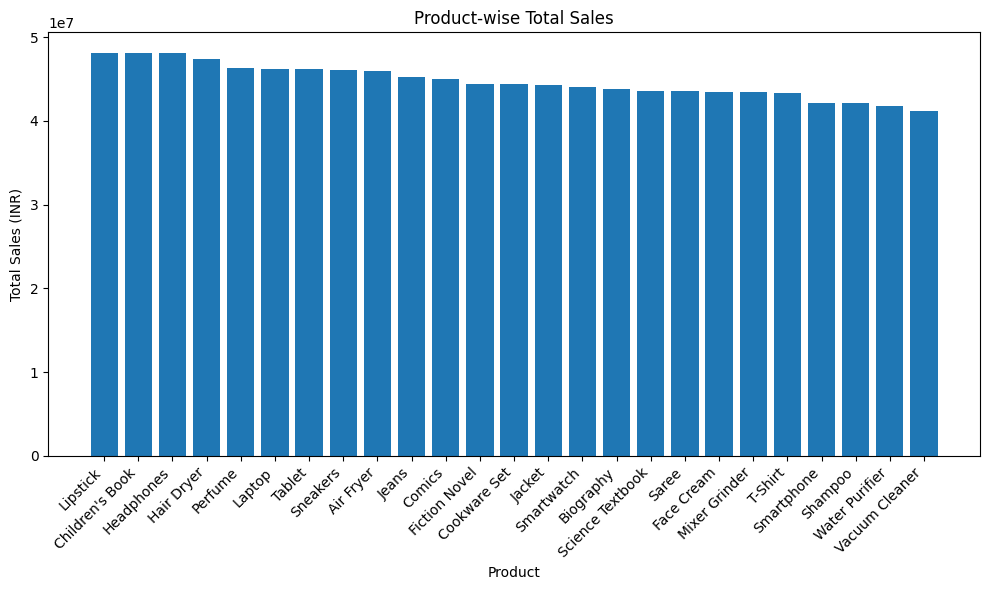

In [120]:
plt.figure(figsize=(10, 6))
plt.bar(product_sales.index, product_sales.values)
plt.xlabel('Product')
plt.ylabel('Total Sales (INR)')
plt.title('Product-wise Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [121]:
df

,Order_ID,Date,Customer_ID,Product_Category,Product_Name,Quantity,Unit_Price_INR,Total_Sales_INR,Payment_Method,Delivery_Status,Review_Rating,Review_Text,State,Country,Month_Name,Month_Num
0,ORD100000,2025-01-25,CUST2796,Home & Kitchen,Cookware Set,2,25574.41,51148.82,Credit Card,Returned,1,Waste of money,Sikkim,India,January,1
1,ORD100001,2025-08-28,CUST9669,Beauty,Hair Dryer,1,19361.41,19361.41,Debit Card,Returned,5,Excellent product!,Telangana,India,August,8
2,ORD100002,2025-02-27,CUST5808,Electronics,Tablet,3,38476.22,115428.66,Cash on Delivery,Delivered,3,Fair deal,Nagaland,India,February,2
3,ORD100003,2025-02-24,CUST5889,Electronics,Headphones,5,38145.72,190728.60,Credit Card,Delivered,5,Highly recommend!,Assam,India,February,2
4,ORD100004,2025-06-15,CUST9005,Clothing,Saree,5,45940.98,229704.90,UPI,Delivered,5,Highly recommend!,Odisha,India,June,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,ORD114995,2025-04-12,CUST2822,Beauty,Lipstick,4,36421.54,145686.16,UPI,Delivered,1,Never buying again,Gujarat,India,April,4
14996,ORD114996,2025-08-29,CUST6143,Beauty,Shampoo,4,18158.02,72632.08,Debit Card,Delivered,4,Satisfied with the product,Meghalaya,India,August,8
14997,ORD114997,2025-01-27,CUST6747,Books,Science Textbook,1,38864.05,38864.05,UPI,Delivered,1,Waste of money,Sikkim,India,January,1
14998,ORD114998,2025-06-21,CUST2748,Beauty,Hair Dryer,3,32658.62,97975.86,Cash on Delivery,Pending,3,Okay product,Himachal Pradesh,India,June,6


In [122]:
state_sales = (df.groupby('State')['Total_Sales_INR'].sum().sort_values(ascending=False))

In [123]:
state_sales

State
Sikkim               43113469.51
Rajasthan            42906175.08
Chhattisgarh         42857545.27
Meghalaya            42773152.96
Tamil Nadu           41967968.99
Uttar Pradesh        41690917.07
Bihar                41669240.44
West Bengal          41195932.45
Tripura              41103376.81
Odisha               40924381.38
Goa                  40488243.03
Madhya Pradesh       39961650.61
Manipur              39934040.52
Punjab               39640897.69
Jharkhand            39606674.07
Arunachal Pradesh    39348777.94
Kerala               39279218.92
Haryana              39171925.41
Telangana            39077114.06
Assam                38739460.17
Maharashtra          38675511.58
Nagaland             38670484.69
Mizoram              38641789.63
Karnataka            38444302.71
Himachal Pradesh     38182171.87
Uttarakhand          37633617.48
Andhra Pradesh       36237577.25
Gujarat              36226185.91
Name: Total_Sales_INR, dtype: float64

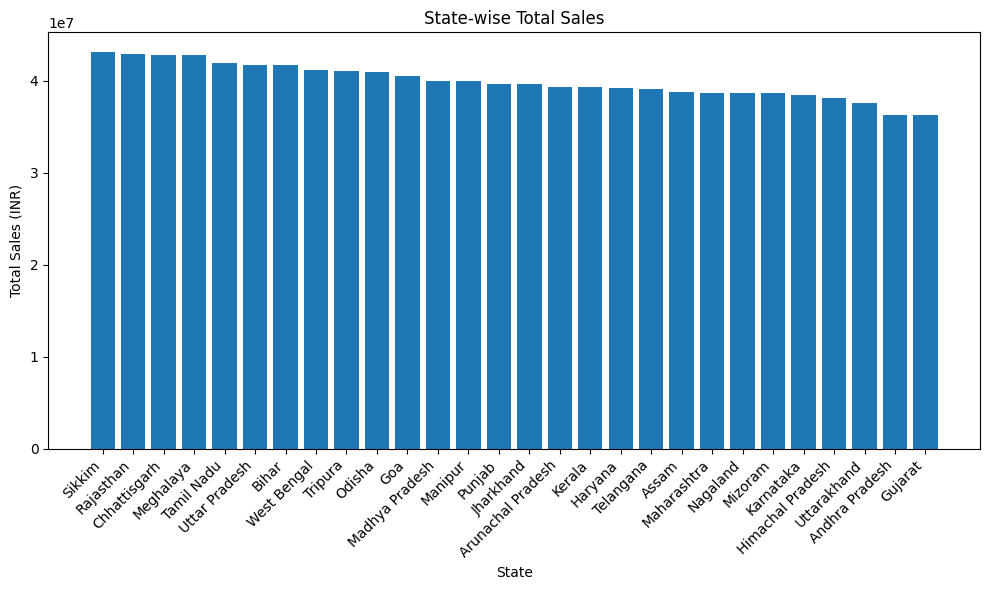

In [124]:
plt.figure(figsize=(10, 6))
plt.bar(state_sales.index, state_sales.values)
plt.xlabel('State')
plt.ylabel('Total Sales (INR)')
plt.title('State-wise Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [134]:
payment_sales = (df.groupby('Payment_Method')['Total_Sales_INR'].sum().sort_values(ascending=False))


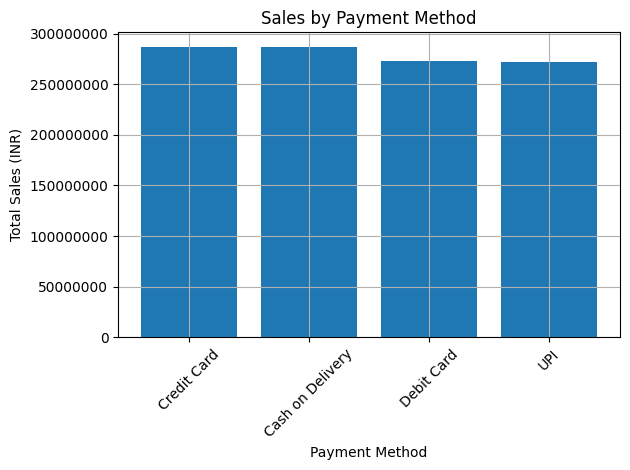

In [135]:

plt.figure()
plt.bar(payment_sales.index, payment_sales.values)
plt.xlabel('Payment Method')
plt.ylabel('Total Sales (INR)')
plt.title('Sales by Payment Method')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')  
plt.tight_layout()
plt.grid()
plt.show()